In [168]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt

In [169]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782625406.log")
assert p.exists()

In [170]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

101210


[simulation_start_ts=1782632597] [unix_ts=1782632672] [frame=4135] [level=INFO] animal_despawn reason=collision lifetime_frames=45 animal=Animal { id: 1672728488766469257, parent_id: Some(2051559386070271829), diet: Carnivore, position: Vec2(168.19554, -282.82016), velocity: Vec2(0.2848931, -0.3666129), energy: 0.0, size: 10.0, color: Srgba(Srgba { red: 1.0, green: 0.0, blue: 0.0, alpha: 1.0 }), vision: Vision { range: 90.0 }, genome: Genome { genes: [] }, spawn_at: 4090, despawn_at: Some(4135), family: 3885824642 }


In [171]:
def extract_animal_data(line):
    # Match new log format: [unix_ts=...] [frame=...] animal_despawn reason=... lifetime_frames=... animal=Animal { ... }
    pat = (
        r".*"
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_timestamp>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"animal_despawn "
        r"reason=(?P<reason>\w+) "
        r"lifetime_frames=(?P<lifetime>\d+) "
        r"animal=Animal\s*\{ "
        r"id:\s*(?P<id>\d+),\s*"
        r"parent_id:\s*Some\((?P<parent_id>\d+|None)\),\s*"
        r"diet:\s*(?P<diet>\w+),\s*"
        r".*"
        r"family:\s*(?P<family>\d+)\s*\}"
        r".*"
    )

    m = re.match(
        pat,
        line,
    )

    if m is not None:
        d = {}
        d["simulation_start_ts"] = m.group("simulation_start_ts")
        d["unix_timestamp"] = float(m.group("unix_timestamp"))
        d["lifetime"] = float(m.group("lifetime"))
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        d["id"] = int(m.group("id"))
        d["parent_id"] = m.group("parent_id")
        return d
    return None


In [172]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))


In [173]:
df

,simulation_start_ts,unix_timestamp,lifetime,diet,family,id,parent_id
0,1782625406,1.782625e+09,271.0,Herbivore,1108152233,8969471488495233910,2744793748041857649
1,1782625406,1.782625e+09,232.0,Herbivore,1108152233,18174151889214241227,2744793748041857649
2,1782625406,1.782625e+09,285.0,Herbivore,1108152233,14523594457312249300,2744793748041857649
3,1782625406,1.782625e+09,281.0,Herbivore,1108152233,18048647065127866874,2744793748041857649
4,1782625406,1.782625e+09,288.0,Herbivore,1108152233,9596011368212735604,2744793748041857649
...,...,...,...,...,...,...,...
18774,1782625406,1.782633e+09,2546.0,Omnivore,551986525,6298787555819634698,8285955155330832576
18775,1782625406,1.782633e+09,5343.0,Omnivore,551986525,12247460481342152254,6604262395090808005
18776,1782625406,1.782633e+09,1478.0,Omnivore,551986525,10968766391401177,5968417664819252934
18777,1782625406,1.782633e+09,40819.0,Omnivore,551986525,5968417664819252934,758294461888884859


In [174]:
df.sort_values("lifetime")

,simulation_start_ts,unix_timestamp,lifetime,diet,family,id,parent_id
11387,1782625406,1.782630e+09,1.0,Herbivore,31306430,582601136330007779,3557656832560655523
14805,1782625406,1.782631e+09,2.0,Carnivore,2627492115,7012724818597049121,7486500239966566091
6317,1782625406,1.782629e+09,2.0,Carnivore,2800176622,1068321487163770999,7472836128188158710
6305,1782625406,1.782629e+09,2.0,Carnivore,2800176622,769568100493724120,17903692355296387302
11406,1782625406,1.782630e+09,2.0,Carnivore,3613813465,10556574350996051210,11713826957308253138
...,...,...,...,...,...,...,...
18709,1782625406,1.782632e+09,20938.0,Carnivore,3648508063,3649116960964813152,10410480578156562218
3449,1782625406,1.782628e+09,24993.0,Omnivore,2958001123,12019519506699613372,17660126294614230274
13502,1782625406,1.782631e+09,26167.0,Carnivore,3648508063,6663122673070130241,4572029805635946396
18403,1782625406,1.782632e+09,26714.0,Carnivore,3648508063,10410480578156562218,15584912896828671912


In [175]:
def extract_population_data(line):
    line = re.sub(
        r"animals=\{carnivores:(\d+)\s+herbivores:(\d+)\s+omnivores:(\d+)\}",
        r'animals={"carnivores":\1,"herbivores":\2,"omnivores":\3}',
        line,
    )
    m = re.match(
        r".*frame=(?P<frame>\d+).*population_size plants=(?P<n_plants>\d+)\s+animals=(?P<json>\{.*?\})\s+families=(?P<families>\d+:\d+(?:\|\d+:\d+)*).*",
        line,
    )
    if m is not None:
        d = {}
        d["frame"] = int(m.group("frame"))
        d["n_plants"] = int(m.group("n_plants"))
        json_data = json.loads(m.group("json"))
        d["carnivores"] = int(json_data.get("carnivores", 0))
        d["herbivores"] = int(json_data.get("herbivores", 0))
        d["omnivores"] = int(json_data.get("omnivores", 0))
        d["families"] = m.group("families")
        return d
    return m     

In [176]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df

,n_plants,carnivores,herbivores,omnivores,families
frame,,,,,
23,10,1,1,0,0:1|348019602:1
24,11,1,1,0,0:1|348019602:1
29,12,1,1,0,0:1|348019602:1
61,13,1,1,0,0:1|348019602:1
64,14,1,1,0,0:1|348019602:1
...,...,...,...,...,...
296839,23,0,1,21,551986525:21|1236051516:1
296854,22,0,1,21,551986525:21|1236051516:1
296859,21,0,1,21,551986525:21|1236051516:1


# Genetic DIversity

In [177]:

df["families"] = df["families"].str.split("|").apply(lambda x: [tuple(map(int, f.split(":"))) for f in x])

<Axes: xlabel='frame'>

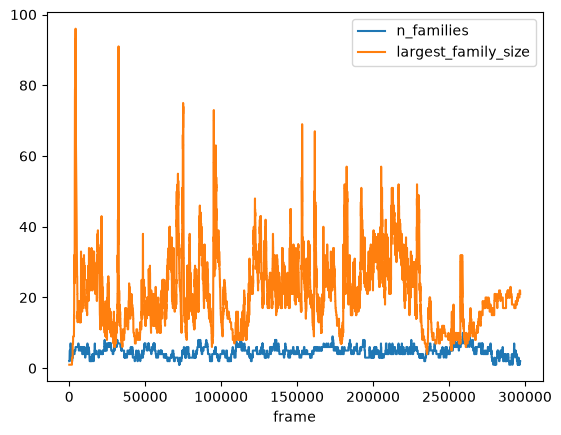

In [178]:
def f(x):
    return {"n_families": len(x), "largest_family_size": max(x, key=lambda i: i[1])[1]}
df_fam = df["families"].apply(f).apply(pd.Series)
df_fam.plot()

# Population

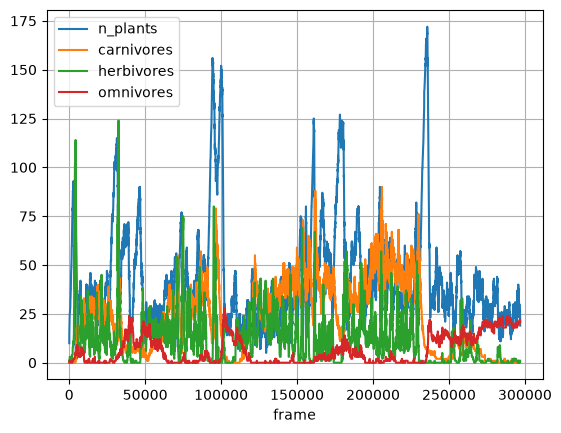

In [179]:
#df["n_plants"].plot()
df.plot()
plt.grid()
plt.legend()